In [1]:
!pip install -U imbalanced-learn xgboost tqdm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')



In [4]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    accuracy_score, f1_score
)


In [5]:
# Imbalanced Learning
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from xgboost import XGBClassifier
import joblib


In [6]:
PROJECT_ROOT = '/content/drive/MyDrive/Depression_Detection_Dataset'

# External data paths (dataset location)
DATASET_DIR  = '/content/drive/MyDrive/Depression_Detection_Dataset/Extracted_Data'
LABELS_DIR   = '/content/drive/MyDrive/Depression_Detection_Dataset/labels'
OUTPUT_DIR   = '/content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text'
print(f"Dataset: {DATASET_DIR}")
print(f"Labels: {LABELS_DIR}")


Dataset: /content/drive/MyDrive/Depression_Detection_Dataset/Extracted_Data
Labels: /content/drive/MyDrive/Depression_Detection_Dataset/labels


In [7]:
# Label files
TRAIN_LABELS_FILE = os.path.join(LABELS_DIR, "train_split.csv")
DEV_LABELS_FILE = os.path.join(LABELS_DIR, "dev_split.csv")
TEST_LABELS_FILE = os.path.join(LABELS_DIR, "test_split.csv")


In [27]:
# internal project dirs
DATA_DIR = os.path.join(OUTPUT_DIR, "data")
FEATURES_DIR = os.path.join(DATA_DIR, "features")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
for directory in [DATA_DIR, FEATURES_DIR, MODELS_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(directory, exist_ok=True)

In [28]:
# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [29]:
# Set Hyperparameters
# Text processing parameters
MAX_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
NGRAM_RANGE = (1, 2)
# Model parameters
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 5
N_FEATURES_TO_SELECT = 1000

print("Hyperparameters configured")

Hyperparameters configured


In [30]:
def normalize_label_column(df):
    """Normalize PHQ label column names across different CSV formats"""
    candidates = ['PHQ8_Binary', 'PHQ_Binary', 'PHQ8_binary', 'PHQ_binary', 'phq8_binary', 'PHQ8']
    for c in candidates:
        if c in df.columns:
            df = df.rename(columns={c: 'PHQ8_Binary'})
            return df
    for c in df.columns:
        if 'PHQ' in c.upper():
            df = df.rename(columns={c: 'PHQ8_Binary'})
            return df
    raise ValueError(f"Could not find PHQ label column in: {df.columns.tolist()}")

In [31]:
def normalize_participant_id_column(df):
    """Normalize participant ID column names"""
    if 'Participant_ID' in df.columns:
        return df
    elif 'participant_ID' in df.columns:
        df = df.rename(columns={'participant_ID': 'Participant_ID'})
        return df
    elif 'participant_id' in df.columns:
        df = df.rename(columns={'participant_id': 'Participant_ID'})
        return df
    else:
        raise ValueError(f"Could not find Participant_ID column")

In [33]:
# Load all label splits
print("Loading label files...")
train_labels = pd.read_csv(TRAIN_LABELS_FILE)
dev_labels = pd.read_csv(DEV_LABELS_FILE)
test_labels = pd.read_csv(TEST_LABELS_FILE)
print("All label files have been Loaded!!")

Loading label files...
All label files have been Loaded!!


In [34]:
# Normalize column names
train_labels = normalize_label_column(train_labels)
train_labels = normalize_participant_id_column(train_labels)
dev_labels = normalize_label_column(dev_labels)
dev_labels = normalize_participant_id_column(dev_labels)
test_labels = normalize_label_column(test_labels)
test_labels = normalize_participant_id_column(test_labels)

In [35]:
all_labels = pd.concat([train_labels, dev_labels, test_labels], ignore_index=True)
all_labels['Participant_ID'] = all_labels['Participant_ID'].astype(str)

print(f"Labels loaded successfully!!")
print(f"   Total participants: {len(all_labels)}")
print(f"   Unique participants: {all_labels['Participant_ID'].nunique()}")

Labels loaded successfully!!
   Total participants: 275
   Unique participants: 275


In [36]:
#Label Distribution
print("\nLabel Distribution:")
print(all_labels['PHQ8_Binary'].value_counts())
print(f"\nClass balance:")
print(all_labels['PHQ8_Binary'].value_counts(normalize=True))


Label Distribution:
PHQ8_Binary
0    209
1     66
Name: count, dtype: int64

Class balance:
PHQ8_Binary
0    0.76
1    0.24
Name: proportion, dtype: float64


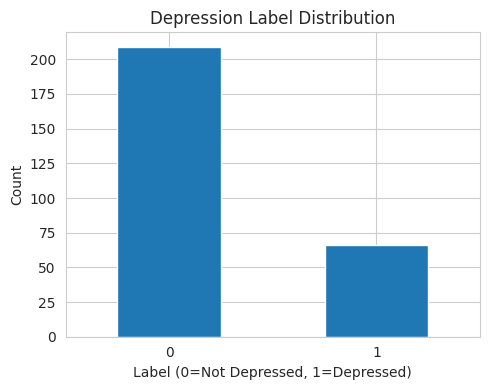

In [37]:
# Visualize label distribution
plt.figure(figsize=(5, 4))
all_labels['PHQ8_Binary'].value_counts().plot(kind='bar')
plt.title('Depression Label Distribution')
plt.xlabel('Label (0=Not Depressed, 1=Depressed)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
def clean_text(text):
    if pd.isna(text) or text == '':
        return ''

    # Remove timestamp
    text = re.sub(r'\d+\.\d+,\s*\d+\.\d+,', '', text)

    # Remove confidence scores
    text = re.sub(r',\s*0\.\d+', '', text)

    # Remove standalone timestamps
    text = re.sub(r'\d+\.\d+,', '', text)

    # Remove standalone numbers
    text = re.sub(r'\b\d+\b', '', text)

    # Remove extra commas
    text = re.sub(r',+', ',', text)
    text = text.strip(',')

    # Remove special characters (keep basic punctuation)
    text = re.sub(r'[^a-zA-Z\s\.\,\?\!\'\-]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)

    # Strip whitespace
    text = text.strip()

    return text

In [39]:
sample_dirty = "2.1,3.2, Hello, 0.9876289963722229 how are you 123 today?"
sample_clean = clean_text(sample_dirty)
print(f"Original: {sample_dirty}")
print(f"Cleaned:  {sample_clean}")

Original: 2.1,3.2, Hello, 0.9876289963722229 how are you 123 today?
Cleaned:  hello how are you today?


In [40]:
def extract_transcript_from_csv(file_path):
    try:
        # Read transcript file (tab-separated)
        df = pd.read_csv(file_path, sep='\t', header=0,
                        names=['start_time', 'stop_time', 'text', 'confidence'])

        # Extract text column
        if 'text' in df.columns:
            texts = df['text'].dropna().astype(str).tolist()
        elif df.shape[1] >= 3:
            texts = df.iloc[:, 2].dropna().astype(str).tolist()
        else:
            texts = df.values.flatten()

        # Combine all text
        full_text = ' '.join(texts)

        # Clean the text
        cleaned_text = clean_text(full_text)

        return cleaned_text

    except Exception as e:
        # Try alternative reading method
        try:
            df = pd.read_csv(file_path, sep='\t', header=None)

            # Skip header row if detected
            if df.shape[0] > 0:
                first_row = df.iloc[0].astype(str).str.lower()
                if any('starttime' in str(val) or 'text' in str(val) for val in first_row):
                    df = df.iloc[1:]

            # Extract text (3rd column)
            if df.shape[1] >= 3:
                texts = df.iloc[:, 2].dropna().astype(str).tolist()
            else:
                texts = df.values.flatten()

            full_text = ' '.join(texts)
            cleaned_text = clean_text(full_text)

            return cleaned_text

        except Exception as e2:
            raise Exception(f"Error reading transcript: {e2}")


In [41]:
all_participant_ids = all_labels['Participant_ID'].tolist()
all_transcripts = []
missing_files = []
empty_transcripts = []

In [42]:
print(f"\nExtracting transcripts for {len(all_participant_ids)} participants...")

for pid in tqdm(all_participant_ids, desc="Processing"):
    pid_str = str(pid)
    folder_name = f"{pid_str}_P"
    file_name = f"{pid_str}_Transcript.csv"
    file_path = os.path.join(DATASET_DIR, folder_name, file_name)

    try:
        cleaned_text = extract_transcript_from_csv(file_path)

        if cleaned_text and len(cleaned_text) > 10:
            all_transcripts.append({
                'Participant_ID': pid_str,
                'transcript': cleaned_text
            })
        else:
            empty_transcripts.append(pid_str)

    except Exception as e:
        missing_files.append(file_path)

print(f"\nExtraction complete!!!")
print(f"   Successfully extracted: {len(all_transcripts)}")
print(f"   Empty transcripts: {len(empty_transcripts)}")



Extracting transcripts for 275 participants...


Processing: 100%|██████████| 275/275 [00:03<00:00, 79.69it/s]


Extraction complete!!!
   Successfully extracted: 275
   Empty transcripts: 0


In [43]:
df_transcripts = pd.DataFrame(all_transcripts)


In [44]:
df_transcripts.head()

,Participant_ID,transcript
0,302,just move around a little bit when you're fini...
1,303,wow okay when you're finished when she's done ...
2,304,so we'll just move around a little bit tonight...
3,305,okay looks good so we can just move around a l...
4,307,looking at you all right okay so now let's mak...


In [45]:
#Merge Transcripts with Labels
all_labels = all_labels.rename(columns={'PHQ8_Binary': 'label'})
df = pd.merge(df_transcripts, all_labels[['Participant_ID', 'label']],
              on='Participant_ID', how='inner')
print(f"\n Final dataset shape: {df.shape}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())


 Final dataset shape: (275, 3)

Label distribution:
label
0    209
1     66
Name: count, dtype: int64


In [46]:
df.head()

,Participant_ID,transcript,label
0,302,just move around a little bit when you're fini...,0
1,303,wow okay when you're finished when she's done ...,0
2,304,so we'll just move around a little bit tonight...,0
3,305,okay looks good so we can just move around a l...,0
4,307,looking at you all right okay so now let's mak...,0


In [47]:
df[df["label"]==0].head()

,Participant_ID,transcript,label
0,302,just move around a little bit when you're fini...,0
1,303,wow okay when you're finished when she's done ...,0
2,304,so we'll just move around a little bit tonight...,0
3,305,okay looks good so we can just move around a l...,0
4,307,looking at you all right okay so now let's mak...,0


In [48]:
df[df["label"]==1].head()

,Participant_ID,transcript,label
5,308,okay perfect so we just want to move around a ...,1
6,309,there we go bring up virtual human chat with h...,1
8,311,now you go ahead and start at the virtual huma...,1
15,319,picking you up to how to do something frank's ...,1
24,330,i want i want to build a program with one of t...,1


In [49]:
df[df["label"]==1].tail()

,Participant_ID,transcript,label
260,688,hi i'm ellie i'm pleased yes i'm doing okay ju...,1
261,689,okay okay okay okay goodbye okay okay i'll tur...,1
265,699,okay seconds or more go ahead and press that b...,1
266,705,causes for seconds from or go ahead and press ...,1
272,716,not very typical to that happen but just in ca...,1


In [50]:
df['text_length'] = df['transcript'].str.len()
df['word_count'] = df['transcript'].str.split().str.len()
print(f"\nText Statistics:")
print(f"   Average length: {df['text_length'].mean():.0f} characters")
print(f"   Average words: {df['word_count'].mean():.0f} words")
print(f"   Min length: {df['text_length'].min()}")
print(f"   Max length: {df['text_length'].max()}")



Text Statistics:
   Average length: 6529 characters
   Average words: 1305 words
   Min length: 872
   Max length: 20885


In [51]:
X_text = df['transcript']
y = df['label']
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Data split complete!!")
print(f"Training samples: {len(X_train_text)}")
print(f"Testing samples: {len(X_test_text)}")
print(f"Training label distribution:\n{y_train.value_counts()}")
print(f"Test label distribution:\n{y_test.value_counts()}")

Data split complete!!
Training samples: 220
Testing samples: 55
Training label distribution:
label
0    167
1     53
Name: count, dtype: int64
Test label distribution:
label
0    42
1    13
Name: count, dtype: int64


In [52]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=MIN_DF,
    max_df=MAX_DF,
    ngram_range=NGRAM_RANGE,
    stop_words='english',
    strip_accents='unicode',
    lowercase=True
)

In [53]:
X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf = vectorizer.transform(X_test_text)

print(f" TF-IDF vectorization complete")
print(f"   Feature matrix shape: {X_train_tfidf.shape}")
print(f"   Vocabulary size: {len(vectorizer.vocabulary_)}")

 TF-IDF vectorization complete
   Feature matrix shape: (220, 5000)
   Vocabulary size: 5000


In [54]:
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")


Sample features: ['abandoned', 'abilities', 'ability', 'able', 'able come', 'able control', 'able deal', 'able focus', 'able handle', 'able help', 'able know', 'able make', 'able sleep', 'able talk', 'absolutely', 'abuse', 'abusive', 'academy', 'accept', 'acceptance']


In [55]:
# Feature Selection (Chi-Square)
selector = SelectKBest(chi2, k=min(N_FEATURES_TO_SELECT, X_train_tfidf.shape[1]))
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected = selector.transform(X_test_tfidf)
print(f"Feature selection complete!!")
print(f"Selected features: {X_train_selected.shape[1]}")

Feature selection complete!!
Selected features: 1000


In [56]:
# Get top features by chi-square score
scores = selector.scores_
top_feature_indices = np.argsort(scores)[-20:][::-1]
top_features = [(feature_names[i], scores[i]) for i in top_feature_indices if not np.isnan(scores[i])]

print(f"\n Top 10 features by chi-square score:")
for feat, score in top_features[:10]:
    print(f"   {feat}: {score:.2f}")


 Top 10 features by chi-square score:
   cheating: 1.63
   seek help: 1.40
   tower: 1.28
   seek: 1.09
   breast: 1.04
   breast cancer: 1.04
   comp: 0.93
   workman comp: 0.93
   workman: 0.93
   quite time: 0.91


In [57]:
#Handle Class Imbalance with SMOTETomek
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smt.fit_resample(X_train_selected.toarray(), y_train)
print(f" Resampling complete")
print(f"   Original training samples: {len(y_train)}")
print(f"   Resampled training samples: {len(y_train_resampled)}")
print(f"   Resampled label distribution:\n{pd.Series(y_train_resampled).value_counts()}")


 Resampling complete
   Original training samples: 220
   Resampled training samples: 334
   Resampled label distribution:
label
0    167
1    167
Name: count, dtype: int64


In [58]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test_selected.toarray())
print(f" Feature scaling complete")
print(f"   Final training shape: {X_train_scaled.shape}")
print(f"   Final testing shape: {X_test_scaled.shape}")

 Feature scaling complete
   Final training shape: (334, 1000)
   Final testing shape: (55, 1000)


In [59]:
models = [
    ("Logistic Regression", LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    )),
    ("SVM (RBF)", SVC(
        kernel='rbf', class_weight='balanced', probability=True, random_state=RANDOM_STATE
    )),
    ("Random Forest", RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE
    )),
    ("Gradient Boosting", GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE
    )),
    ("XGBoost", XGBClassifier(
        random_state=RANDOM_STATE,
        scale_pos_weight=len(y_train_resampled[y_train_resampled==0]) / len(y_train_resampled[y_train_resampled==1]),
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
]

print("Models defined:")
for name, _ in models:
    print(f"   - {name}")

Models defined:
   - Logistic Regression
   - SVM (RBF)
   - Random Forest
   - Gradient Boosting
   - XGBoost


In [60]:
results = []

In [61]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    # Store results
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Depressed)": report['1']['precision'],
        "Recall (Depressed)": report['1']['recall'],
        "F1-score (Depressed)": report['1']['f1-score'],
        "Precision (Not Depressed)": report['0']['precision'],
        "Recall (Not Depressed)": report['0']['recall'],
        "F1-score (Not Depressed)": report['0']['f1-score']
    })
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Not Depressed (0)', 'Depressed (1)']))
    return model

In [62]:
# Train all models
trained_models = {}
for name, model in models:
    trained_model = evaluate_model(name, model, X_train_scaled, y_train_resampled, X_test_scaled, y_test)
    trained_models[name] = trained_model


Training: Logistic Regression
Accuracy: 0.7818
                   precision    recall  f1-score   support

Not Depressed (0)       0.78      1.00      0.88        42
    Depressed (1)       1.00      0.08      0.14        13

         accuracy                           0.78        55
        macro avg       0.89      0.54      0.51        55
     weighted avg       0.83      0.78      0.70        55


Training: SVM (RBF)
Accuracy: 0.7636
                   precision    recall  f1-score   support

Not Depressed (0)       0.76      1.00      0.87        42
    Depressed (1)       0.00      0.00      0.00        13

         accuracy                           0.76        55
        macro avg       0.38      0.50      0.43        55
     weighted avg       0.58      0.76      0.66        55


Training: Random Forest
Accuracy: 0.7636
                   precision    recall  f1-score   support

Not Depressed (0)       0.76      1.00      0.87        42
    Depressed (1)       0.00      0.00 

In [63]:
print(f"\n{'='*60}")
print("Hyperparameter Tuning: Random Forest")
print('='*60)

param_grid = {
    'n_estimators': [200],
    'max_depth': [15],
    'min_samples_split': [2],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1)
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    rf_base, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=1
)

grid_search.fit(X_train_scaled, y_train_resampled)
best_rf = grid_search.best_estimator_

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"✅ Best CV score: {grid_search.best_score_:.4f}")



Hyperparameter Tuning: Random Forest
Fitting 5 folds for each of 1 candidates, totalling 5 fits

✅ Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV score: 0.8968


In [64]:
#Advanced Ensemble Model
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    min_samples_split=5, min_samples_leaf=2, subsample=0.8,
    random_state=RANDOM_STATE
)
ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('gb', gb)],
    voting='soft',
    weights=[1.5, 1]
)
ensemble_model = evaluate_model(
    "Advanced Ensemble (RF+GB)", ensemble,
    X_train_scaled, y_train_resampled, X_test_scaled, y_test
)


Training: Advanced Ensemble (RF+GB)
Accuracy: 0.8000
                   precision    recall  f1-score   support

Not Depressed (0)       0.79      1.00      0.88        42
    Depressed (1)       1.00      0.15      0.27        13

         accuracy                           0.80        55
        macro avg       0.90      0.58      0.58        55
     weighted avg       0.84      0.80      0.74        55



In [65]:
#Model Comparison Results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("F1-score (Depressed)", ascending=False)

print(f"\n{'='*60}")
print("MODEL COMPARISON TABLE")
print('='*60)
print(results_df.to_string(index=False))


MODEL COMPARISON TABLE
                    Model  Accuracy  Precision (Depressed)  Recall (Depressed)  F1-score (Depressed)  Precision (Not Depressed)  Recall (Not Depressed)  F1-score (Not Depressed)
                  XGBoost  0.818182               0.714286            0.384615              0.500000                   0.833333                0.952381                  0.888889
        Gradient Boosting  0.781818               0.571429            0.307692              0.400000                   0.812500                0.928571                  0.866667
Advanced Ensemble (RF+GB)  0.800000               1.000000            0.153846              0.266667                   0.792453                1.000000                  0.884211
      Logistic Regression  0.781818               1.000000            0.076923              0.142857                   0.777778                1.000000                  0.875000
                SVM (RBF)  0.763636               0.000000            0.000000        

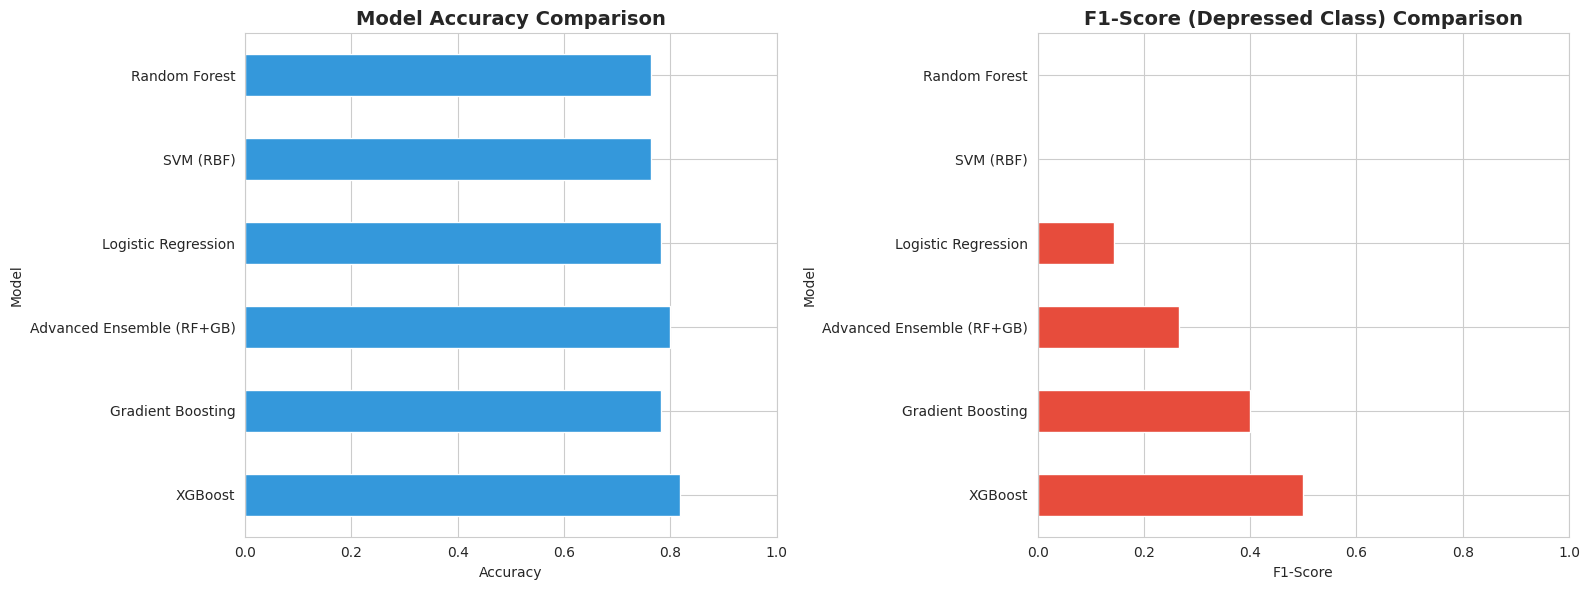

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Accuracy comparison
results_df.plot(x='Model', y='Accuracy', kind='barh', ax=axes[0], color='#3498db', legend=False)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1)

# F1-score comparison
results_df.plot(x='Model', y='F1-score (Depressed)', kind='barh', ax=axes[1], color='#e74c3c', legend=False)
axes[1].set_title('F1-Score (Depressed Class) Comparison', fontsize=14, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [67]:
#Select Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = ensemble_model if "Ensemble" in best_model_name else trained_models[best_model_name]
print(f" Best Model: {best_model_name}")


 Best Model: XGBoost


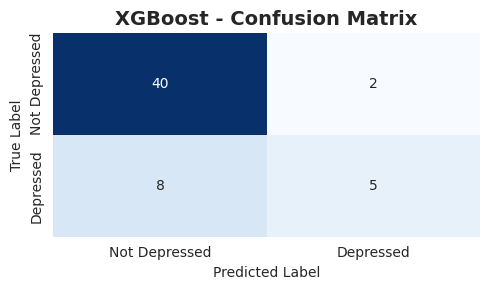

In [68]:
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Depressed', 'Depressed'],
            yticklabels=['Not Depressed', 'Depressed'])
plt.title(f'{best_model_name} - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


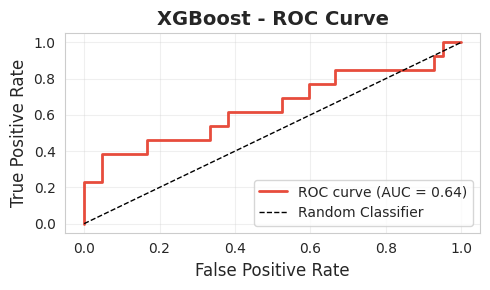

ROC AUC Score: 0.6429


In [69]:
#ROC Curve
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', linewidth=2, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'{best_model_name} - ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"ROC AUC Score: {roc_auc:.4f}")

In [70]:
#Detailed Classification Report
print(f"\n{'='*60}")
print("DETAILED CLASSIFICATION REPORT")
print('='*60)
print(classification_report(y_test, y_pred, target_names=['Not Depressed (0)', 'Depressed (1)']))


DETAILED CLASSIFICATION REPORT
                   precision    recall  f1-score   support

Not Depressed (0)       0.83      0.95      0.89        42
    Depressed (1)       0.71      0.38      0.50        13

         accuracy                           0.82        55
        macro avg       0.77      0.67      0.69        55
     weighted avg       0.81      0.82      0.80        55



In [72]:
# Save Trained Model
# Create the models directory if it doesn't exist
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)
    print(f"Created directory: {MODELS_DIR}")

BEST_MODEL_PATH = os.path.join(MODELS_DIR, "best_text_model.pkl")
VECTORIZER_PATH = os.path.join(MODELS_DIR, "text_vectorizer.pkl")
SCALER_PATH = os.path.join(MODELS_DIR, "text_scaler.pkl")
SELECTOR_PATH = os.path.join(MODELS_DIR, "feature_selector.pkl")

joblib.dump(best_model, BEST_MODEL_PATH)
joblib.dump(vectorizer, VECTORIZER_PATH)
joblib.dump(scaler, SCALER_PATH)
joblib.dump(selector, SELECTOR_PATH)

print(f"Model saved to: {BEST_MODEL_PATH}")
print(f"Vectorizer saved to: {VECTORIZER_PATH}")
print(f"Scaler saved to: {SCALER_PATH}")
print(f"Selector saved to: {SELECTOR_PATH}")

Created directory: /content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text/models
Model saved to: /content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text/models/best_text_model.pkl
Vectorizer saved to: /content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text/models/text_vectorizer.pkl
Scaler saved to: /content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text/models/text_scaler.pkl
Selector saved to: /content/drive/MyDrive/Depression_Detection_Dataset/depression_output_text/models/feature_selector.pkl


In [73]:
def predict_depression_from_text(text, model, vectorizer, scaler, selector):
    if not text or len(text.strip()) < 10:
        raise ValueError("Text is too short. Please provide at least 10 characters.")
    # Clean text
    cleaned_text = clean_text(text)
    # Transform
    text_tfidf = vectorizer.transform([cleaned_text])
    text_selected = selector.transform(text_tfidf)
    text_scaled = scaler.transform(text_selected.toarray())
    # Predict
    prediction = model.predict(text_scaled)[0]
    probability = model.predict_proba(text_scaled)[0]

    result = {
        'prediction': int(prediction),
        'label': 'Depressed' if prediction == 1 else 'Not Depressed',
        'confidence': float(max(probability)),
        'probability_not_depressed': float(probability[0]),
        'probability_depressed': float(probability[1])
    }
    return result

In [74]:
test_texts = [
    "I feel very sad and hopeless. Nothing brings me joy anymore. I can't sleep at night.",
    "I'm doing great! Life is wonderful and I'm excited about the future. Everything is going well.",
    "I don't know how I feel. Sometimes good, sometimes not so good."
]

print(f"\n{'='*60}")
print("TESTING PREDICTIONS ON SAMPLE TEXTS")
print('='*60)

for i, text in enumerate(test_texts, 1):
    result = predict_depression_from_text(text, best_model, vectorizer, scaler, selector)
    print(f"\n[Test {i}]")
    print(f"Text: {text[:80]}...")
    print(f"  Prediction: {result['label']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print(f"   P(Not Depressed): {result['probability_not_depressed']:.2%}")
    print(f"   P(Depressed): {result['probability_depressed']:.2%}")



TESTING PREDICTIONS ON SAMPLE TEXTS

[Test 1]
Text: I feel very sad and hopeless. Nothing brings me joy anymore. I can't sleep at ni...
  Prediction: Not Depressed
  Confidence: 93.79%
   P(Not Depressed): 93.79%
   P(Depressed): 6.21%

[Test 2]
Text: I'm doing great! Life is wonderful and I'm excited about the future. Everything ...
  Prediction: Not Depressed
  Confidence: 99.83%
   P(Not Depressed): 99.83%
   P(Depressed): 0.17%

[Test 3]
Text: I don't know how I feel. Sometimes good, sometimes not so good....
  Prediction: Not Depressed
  Confidence: 99.43%
   P(Not Depressed): 99.43%
   P(Depressed): 0.57%
